# Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import torchvision
import os
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import random
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import json
from tqdm import tqdm
import re
from itertools import groupby
import matplotlib.pyplot as plt

In [3]:
PROJECT_ROOT = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "ProfessionAI_AIengineering/9. Generative AI/"
    "Project_Generative_AI"
)

DATA_DIR = os.path.join(PROJECT_ROOT, "data")
CAPTIONS_DIR = os.path.join(DATA_DIR, "captions")

os.makedirs(CAPTIONS_DIR, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /content/drive/MyDrive/Colab Notebooks/ProfessionAI_AIengineering/9. Generative AI/Project_Generative_AI


In [5]:
!apt-get -qq install tree
# !tree /content/drive/MyDrive/Colab\ Notebooks/ProfessionAI_AIengineering/9.\ Generative\ AI/Project_Generative_AI

Selecting previously unselected package tree.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [6]:
# list only directories
!tree -d /content/drive/MyDrive/Colab\ Notebooks/ProfessionAI_AIengineering/9.\ Generative\ AI/Project_Generative_AI

/content/drive/MyDrive/Colab Notebooks/ProfessionAI_AIengineering/9. Generative AI/Project_Generative_AI
├── data
│   ├── captions
│   ├── raw
│   │   └── oxford-iiit-pet
│   │       ├── annotations
│   │       │   ├── trimaps
│   │       │   └── xmls
│   │       └── images
│   ├── splits
│   ├── synthetic
│   │   └── images
│   │       ├── first run - too long
│   │       └── second run - less accurate
│   ├── test
│   │   └── oxford-iiit-pet
│   │       ├── annotations
│   │       │   ├── trimaps
│   │       │   └── xmls
│   │       └── images
│   └── text_variations
├── models
├── notebooks
├── results
│   ├── figures
│   ├── logs
│   └── metrics
└── utils

27 directories


In [ ]:
INSTALL_DEPS = True   # set to False after first successful run

if INSTALL_DEPS:
    !pip install -r "$PROJECT_ROOT/requirements.txt"

# Load Datasets

In [ ]:
# PROJECT_ROOT

In [ ]:
# load train dataset
dataset_train = torchvision.datasets.OxfordIIITPet(root = os.path.join(PROJECT_ROOT, "data", "raw"),
                                             split = "trainval",
                                             download = True
                                             )

In [ ]:
# print("Number of images:", len(dataset_train))
# print("Number of classes:", len(dataset_train.classes))

### Create 30% Stratified Subset

In [ ]:
# extract labels
labels = dataset_train._labels
indices = np.arange(len(dataset_train))

The stratification below ensures:

- 30% of data

- Class distribution preserved

- Reproducible split

In [ ]:
# perform stratified split
train_small_idx, _ = train_test_split(
    indices,
    train_size=0.30,
    stratify=labels,
    random_state=42
)

In [ ]:
PROJECT_ROOT

'/content/drive/MyDrive/Colab Notebooks/ProfessionAI_AIengineering/9. Generative AI/Project_Generative_AI'

In [ ]:
SPLIT_DIR = os.path.join(PROJECT_ROOT, "data", "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)

np.save(os.path.join(SPLIT_DIR, "train_small_indices.npy"), train_small_idx)

In [ ]:
# create subset dataset from training set
dataset_train_small = Subset(dataset_train, train_small_idx)

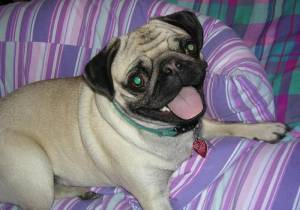

In [ ]:
dataset_train_small[1009][0]

# Load BLIP-2 Captioning Model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Note: consider using a lighter model i.e. Salesforce/blip-image-captioning-base

In [ ]:
# it takes 10 mins with CPU, 5 mins with GPU
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16 # to reduce GPU memory usage
)

model.to(device)
model.eval()

print("BLIP-2 loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

BLIP-2 loaded successfully


In [ ]:
PROMPTS = [
    "Question: Describe the animal's posture and surroundings. Answer:",
    "Question: Describe what the animal is doing and its appearance. Answer:"
]

In [ ]:
CAT_BREEDS = {
    "Abyssinian",
    "Bengal",
    "Birman",
    "Bombay",
    "British Shorthair",
    "Egyptian Mau",
    "Maine Coon",
    "Persian",
    "Ragdoll",
    "Russian Blue",
    "Siamese",
    "Sphynx"
}

In [ ]:
ALL_BREEDS = set(dataset_train_small.dataset.classes)
ALL_BREEDS_LOWER = {b.lower() for b in ALL_BREEDS}

In [ ]:
def generate_captions(image, class_name):
  captions = []

  # determine animal type
  animal_type = "cat" if class_name in CAT_BREEDS else "dog"
  class_name_lower = class_name.lower()

  for prompt in PROMPTS:
    inputs = processor(images=image,
                       text=prompt,
                       return_tensors="pt"
                       ).to(device)

    with torch.no_grad(): # cause we are only generating captions (= doing inference) and not training
      output = model.generate(
                **inputs,
                max_new_tokens=40,
                min_new_tokens = 5,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                num_beams = 3,
                early_stopping = True,
                do_sample = False)

    caption = processor.decode(output[0],
                               skip_special_tokens=True)

    # Normalize early
    caption = caption.strip().lower()

    # Remove Q/A prefix
    if "answer:" in caption:
        caption = caption.split("answer:")[-1].strip()

    # Remove leading articles
    for article in ["the ", "a ", "an "]:
        if caption.startswith(article):
            caption = caption[len(article):]

    # Remove hallucinated breed names
    for breed in ALL_BREEDS_LOWER:
        # caption = caption.replace(breed, "")
        caption = re.sub(rf"\b{breed}\b", "", caption)

    # Remove leading animal words
    for animal_word in ["cat ", "dog "]:
        if caption.startswith(animal_word):
            caption = caption[len(animal_word):]

    # Remove duplicate spaces
    caption = " ".join(caption.split())


    # If caption becomes empty, fallback to generic description
    if not caption:
        final_caption = f"a {class_name_lower} {animal_type}"
    else:
        final_caption = f"a {class_name_lower} {animal_type} {caption}"

    final_caption = " ".join(word for word, _ in groupby(final_caption.split())) # remove consecutive duplicates

    captions.append(final_caption.strip())

  return captions

In [ ]:
# initialize JSON
CAPTION_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "captions",
    "captions_train_small.json"
)

In [ ]:
# Create captions folder if missing
os.makedirs(os.path.dirname(CAPTION_PATH), exist_ok=True)

# Force overwrite
if os.path.exists(CAPTION_PATH):
    os.remove(CAPTION_PATH)

captions_dict = {}

In [ ]:
# # Safe Caption Loop (Test Version)

# for i in tqdm(range(15)):  # temporary small test

#     # if str(i) in captions_dict:
#     #     continue

#     img, label = dataset_train_small[i]
#     img = img.convert("RGB")

#     class_name = dataset_train_small.dataset.classes[label]

#     captions = generate_captions(img, class_name)

#     captions_dict[str(i)] = {
#         "class_name": class_name,
#         "captions": captions
#     }

#     # Save immediately for test
#     with open(CAPTION_PATH, "w") as f:
#         json.dump(captions_dict, f, indent=2)

# print("Test captions saved (overwritten).")


In [ ]:
# # grid plot
# # Load captions
# with open(CAPTION_PATH, "r") as f:
#     captions_dict = json.load(f)

# num_samples = 15
# cols = 3
# rows = 5

# plt.figure(figsize=(10,12))

# for i in range(num_samples):
#   img, label = dataset_train_small[i]
#   img = img.convert("RGB")

#   captions = captions_dict[str(i)]["captions"]

#   caption_text = "\n".join(captions)
#   plt.subplot(rows, cols, i + 1)
#   plt.imshow(img)
#   plt.axis("off")
#   plt.title(caption_text, fontsize=8)

# plt.tight_layout()
# plt.show()


# Caption Generation

In [ ]:
# full Caption loop (with GPU)

model.eval()
torch.cuda.empty_cache()

for i in tqdm(range(len(dataset_train_small))):

    img, label = dataset_train_small[i]
    img = img.convert("RGB")

    class_name = dataset_train_small.dataset.classes[label]

    captions = generate_captions(img, class_name)

    captions_dict[str(i)] = {
        "class_name": class_name,
        "captions": captions
    }

    # Save every 20 samples
    if i % 20 == 0:
        with open(CAPTION_PATH, "w") as f:
            json.dump(captions_dict, f, indent=2)

# Final save
with open(CAPTION_PATH, "w") as f:
    json.dump(captions_dict, f, indent=2)

print("Full caption generation completed.")


100%|██████████| 1104/1104 [24:23<00:00,  1.33s/it]

Full caption generation completed.


# Visual Sanity Check

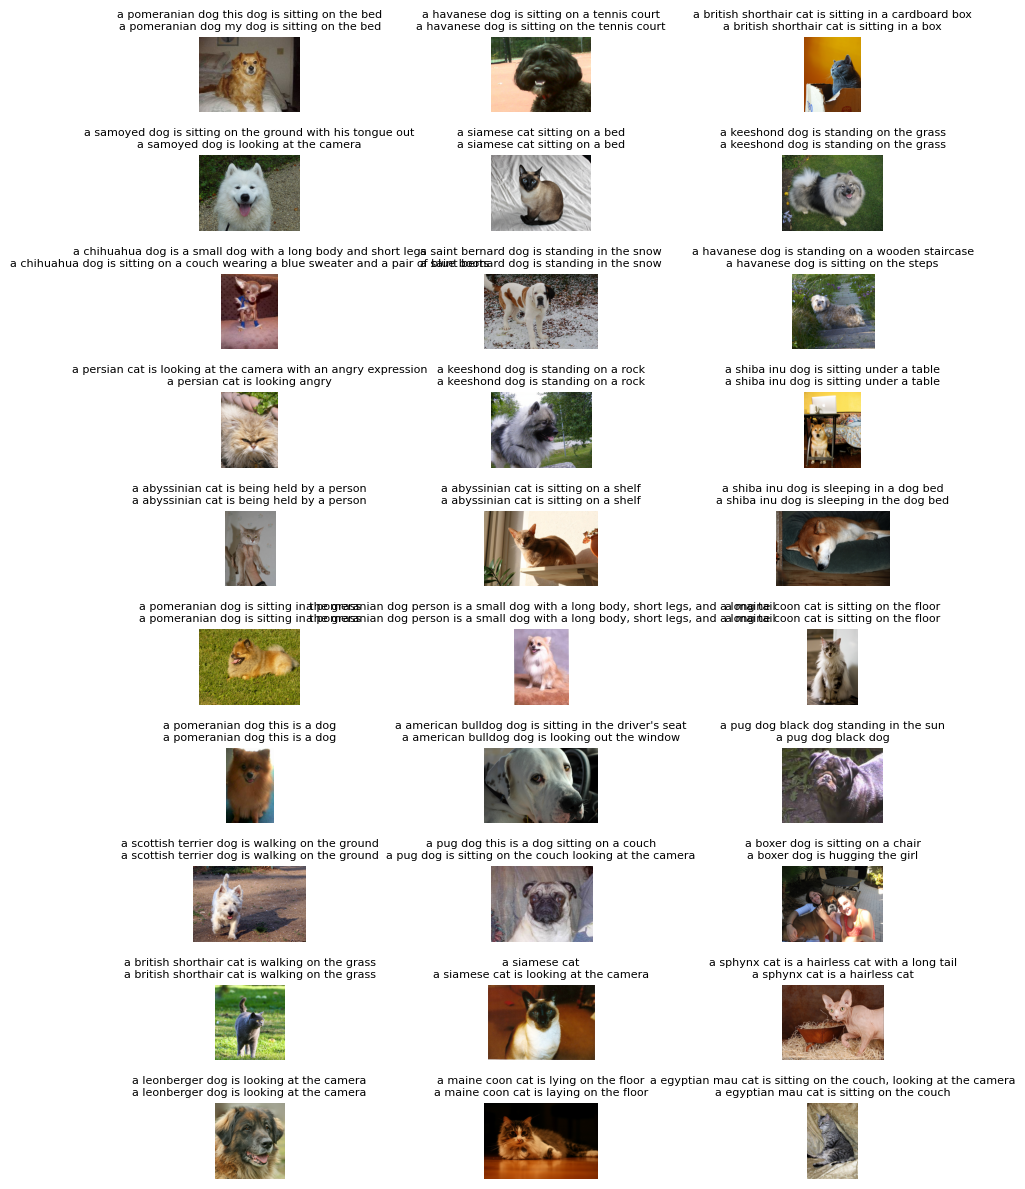

In [ ]:
# grid plot
# Load captions
with open(CAPTION_PATH, "r") as f:
    captions_dict = json.load(f)

num_samples = 30
cols = 3
rows = 10

plt.figure(figsize=(10,12))

for i in range(num_samples):
  img, label = dataset_train_small[i]
  img = img.convert("RGB")

  captions = captions_dict[str(i)]["captions"]

  caption_text = "\n".join(captions)
  plt.subplot(rows, cols, i + 1)
  plt.imshow(img)
  plt.axis("off")
  plt.title(caption_text, fontsize=8)

plt.tight_layout()
plt.show()